# YOLO Inference on Test Set

This notebook loads the best trained model and runs inference on the test set for visualization.

In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

from ultralytics import YOLO

## Configuration

In [2]:
# Experiment configuration
EXP_NUM = "0001"

# Paths
PROJECT_ROOT = Path.cwd().parent
RUNS_DIR = PROJECT_ROOT / "runs"
EXP_DIR = RUNS_DIR / f"EXP{EXP_NUM}"
WEIGHTS_PATH = EXP_DIR / "weights" / "best.pt"

# Test data path
DATA_ROOT = Path("/home/jhkim/NAVA/NAVA_original/500_YOLO_Data")
TEST_PATIENTS = ["04"]

print(f"Experiment directory: {EXP_DIR}")
print(f"Weights path: {WEIGHTS_PATH}")
print(f"Weights exists: {WEIGHTS_PATH.exists()}")

Experiment directory: /home/jhkim/NAVA/02_YOLO/runs/EXP0001
Weights path: /home/jhkim/NAVA/02_YOLO/runs/EXP0001/weights/best.pt
Weights exists: True


## Load Model

In [3]:
# Load the trained model
model = YOLO(str(WEIGHTS_PATH))
print(f"Model loaded from: {WEIGHTS_PATH}")

Model loaded from: /home/jhkim/NAVA/02_YOLO/runs/EXP0001/weights/best.pt


## Get Test Images

In [4]:
# Collect test images from test patients
test_images = []
for patient_id in TEST_PATIENTS:
    patient_img_dir = DATA_ROOT / patient_id / "images"
    if patient_img_dir.exists():
        test_images.extend(list(patient_img_dir.glob("*.png")))

test_images = sorted(test_images)
print(f"Found {len(test_images)} test images")
print(f"Sample images: {[img.name for img in test_images[:3]]}")

Found 50 test images
Sample images: ['p04_file_1_window_0000.png', 'p04_file_1_window_0001.png', 'p04_file_1_window_0002.png']


## Helper Functions

In [5]:
def load_yolo_labels(label_path, img_width, img_height):
    """
    Load YOLO format labels and convert to pixel coordinates.
    
    Args:
        label_path: Path to the label .txt file
        img_width: Image width in pixels
        img_height: Image height in pixels
    
    Returns:
        List of boxes in [x_min, y_min, x_max, y_max] format
    """
    boxes = []
    if not Path(label_path).exists():
        return boxes
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                # YOLO format: class x_center y_center width height (normalized)
                x_center = float(parts[1]) * img_width
                y_center = float(parts[2]) * img_height
                width = float(parts[3]) * img_width
                height = float(parts[4]) * img_height
                
                x_min = x_center - width / 2
                y_min = y_center - height / 2
                x_max = x_center + width / 2
                y_max = y_center + height / 2
                
                boxes.append([x_min, y_min, x_max, y_max])
    
    return boxes


def draw_boxes(ax, boxes, color, linewidth=2):
    """
    Draw bounding boxes on an axes without labels.
    
    Args:
        ax: Matplotlib axes
        boxes: List of boxes in [x_min, y_min, x_max, y_max] format
        color: Box color
        linewidth: Line width
    """
    for box in boxes:
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        
        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=linewidth,
            edgecolor=color,
            facecolor='none'
        )
        ax.add_patch(rect)

## Run Inference and Visualize

In [ ]:
def visualize_predictions_with_gt(image_path, results, figsize=(14, 5)):
    """
    Visualize YOLO predictions and ground truth on an image.
    
    - Ground truth: Blue boxes
    - Predictions: Red boxes
    
    Args:
        image_path: Path to the original image
        results: YOLO inference results
        figsize: Figure size
    """
    image_path = Path(image_path)
    
    # Get corresponding label path
    label_path = image_path.parent.parent / "labels" / (image_path.stem + ".txt")
    
    # Load image
    img = Image.open(image_path)
    img_array = np.array(img)
    img_width, img_height = img.size
    
    # Load ground truth boxes
    gt_boxes = load_yolo_labels(label_path, img_width, img_height)
    
    # Get prediction boxes
    pred_boxes = []
    if len(results[0].boxes) > 0:
        for box in results[0].boxes:
            xyxy = box.xyxy[0].cpu().numpy()
            pred_boxes.append(xyxy.tolist())
    
    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Left: Original image with ground truth (blue boxes)
    axes[0].imshow(img_array)
    draw_boxes(axes[0], gt_boxes, color='blue', linewidth=2)
    axes[0].set_title(f'Ground Truth ({len(gt_boxes)} boxes)', fontsize=12)
    axes[0].axis('off')
    
    # Right: Original image with predictions (red boxes)
    axes[1].imshow(img_array)
    draw_boxes(axes[1], pred_boxes, color='red', linewidth=2)
    axes[1].set_title(f'Predictions ({len(pred_boxes)} boxes)', fontsize=12)
    axes[1].axis('off')
    
    plt.suptitle(image_path.name, fontsize=14, y=0.85)
    plt.tight_layout()
    plt.savefig(f"outputs/{image_path.name}")
    
    return len(gt_boxes), len(pred_boxes)


Image 1/5: p04_file_1_window_0000.png
Ground truth boxes: 10
Predicted boxes: 10

Image 2/5: p04_file_1_window_0001.png
Ground truth boxes: 5
Predicted boxes: 7

Image 3/5: p04_file_1_window_0002.png
Ground truth boxes: 4
Predicted boxes: 5

Image 4/5: p04_file_1_window_0003.png
Ground truth boxes: 10
Predicted boxes: 14

Image 5/5: p04_file_1_window_0004.png
Ground truth boxes: 11
Predicted boxes: 9


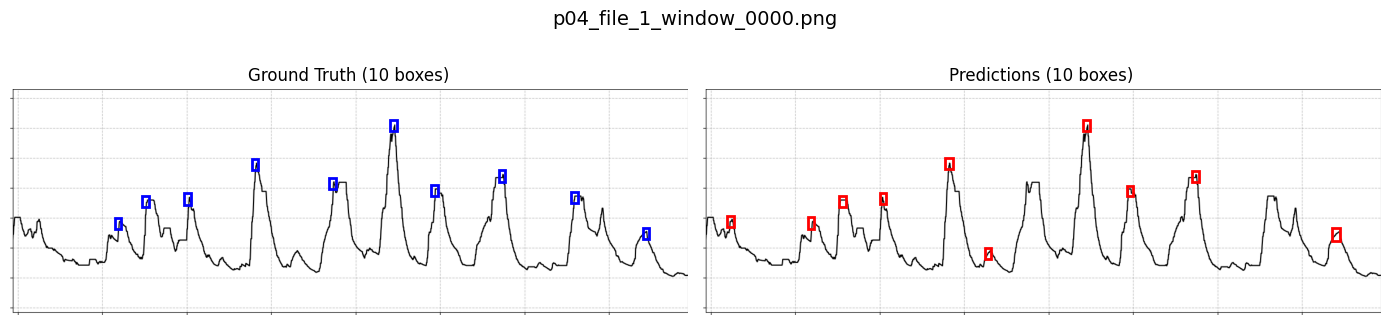

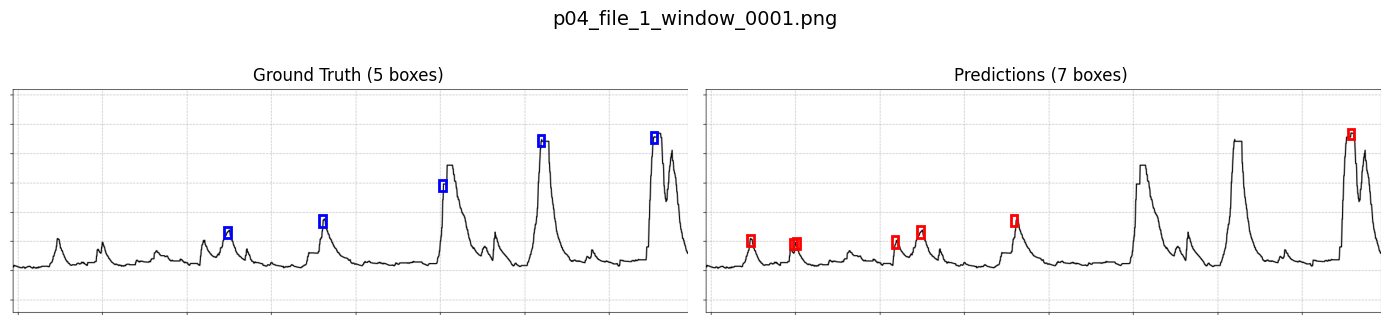

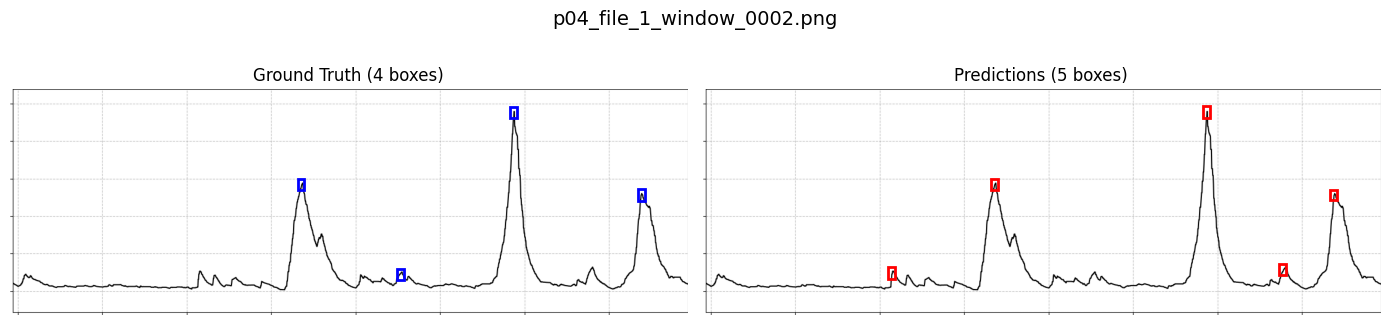

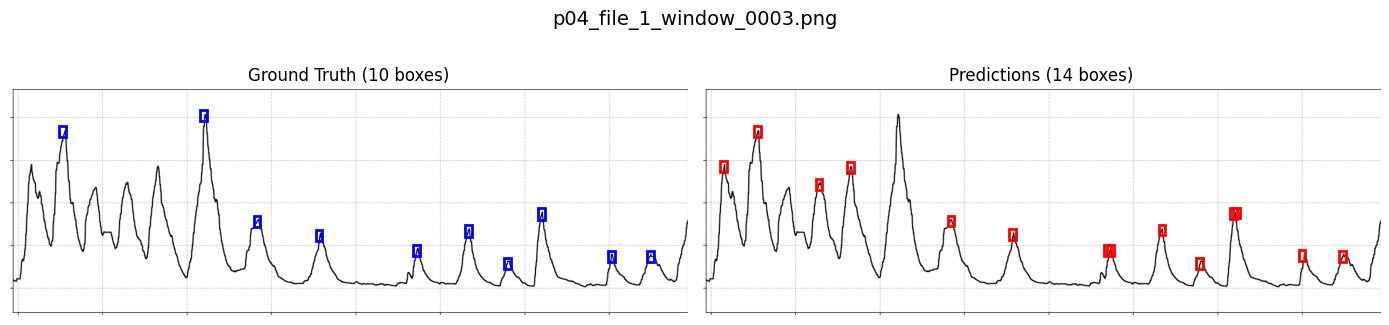

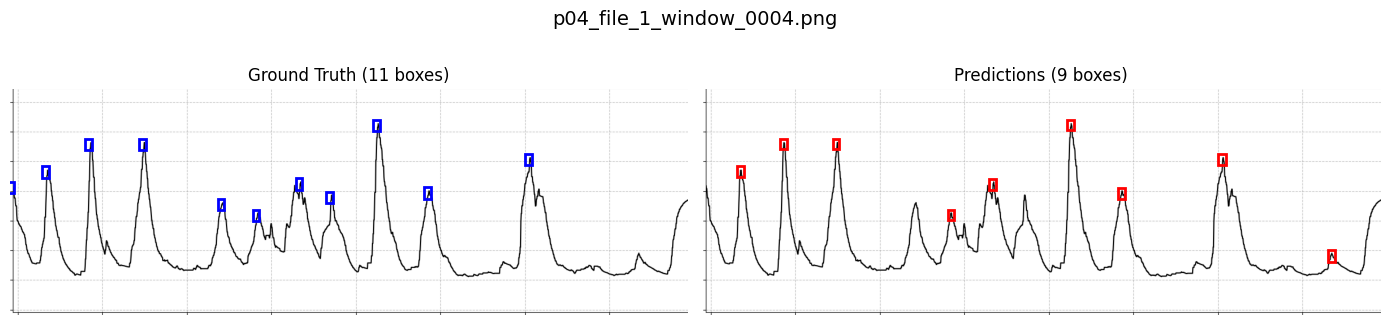

In [7]:
# Run inference on first N images
N_SAMPLES = 5  # Number of images to visualize

for i, img_path in enumerate(test_images[:N_SAMPLES]):
    print(f"\n{'='*60}")
    print(f"Image {i+1}/{N_SAMPLES}: {img_path.name}")
    
    # Run inference
    results = model.predict(
        source=str(img_path),
        conf=0.25,  # Confidence threshold
        iou=0.45,   # IoU threshold for NMS
        verbose=False
    )
    
    # Visualize with ground truth
    n_gt, n_pred = visualize_predictions_with_gt(img_path, results)
    
    print(f"Ground truth boxes: {n_gt}")
    print(f"Predicted boxes: {n_pred}")

## Batch Inference on All Test Images

In [ ]:
# Run batch inference on all test images
all_results = model.predict(
    source=[str(img) for img in test_images],
    conf=0.25,
    iou=0.45,
    verbose=False
)

# Calculate statistics
total_detections = sum(len(r.boxes) for r in all_results)
images_with_detections = sum(1 for r in all_results if len(r.boxes) > 0)

print(f"\n{'='*60}")
print(f"Batch Inference Summary")
print(f"{'='*60}")
print(f"Total test images: {len(test_images)}")
print(f"Total detections: {total_detections}")
print(f"Images with detections: {images_with_detections}")
print(f"Average detections per image: {total_detections / len(test_images):.2f}")

## Save Predictions (Optional)

In [ ]:
# Save predictions to a directory
SAVE_PREDICTIONS = False  # Set to True to save
SAVE_DIR = EXP_DIR / "test_predictions"

if SAVE_PREDICTIONS:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    
    for img_path, result in zip(test_images, all_results):
        img_path = Path(img_path)
        label_path = img_path.parent.parent / "labels" / (img_path.stem + ".txt")
        
        img = Image.open(img_path)
        img_array = np.array(img)
        img_width, img_height = img.size
        
        gt_boxes = load_yolo_labels(label_path, img_width, img_height)
        pred_boxes = [box.xyxy[0].cpu().numpy().tolist() for box in result.boxes]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].imshow(img_array)
        draw_boxes(axes[0], gt_boxes, color='blue', linewidth=2)
        axes[0].set_title(f'Ground Truth ({len(gt_boxes)} boxes)')
        axes[0].axis('off')
        
        axes[1].imshow(img_array)
        draw_boxes(axes[1], pred_boxes, color='red', linewidth=2)
        axes[1].set_title(f'Predictions ({len(pred_boxes)} boxes)')
        axes[1].axis('off')
        
        plt.suptitle(img_path.name)
        plt.tight_layout()
        
        save_path = SAVE_DIR / f"{img_path.stem}_comparison.png"
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.close()
    
    print(f"Predictions saved to: {SAVE_DIR}")
else:
    print("Set SAVE_PREDICTIONS = True to save prediction images")